In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.shape

(1025, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

<Axes: >

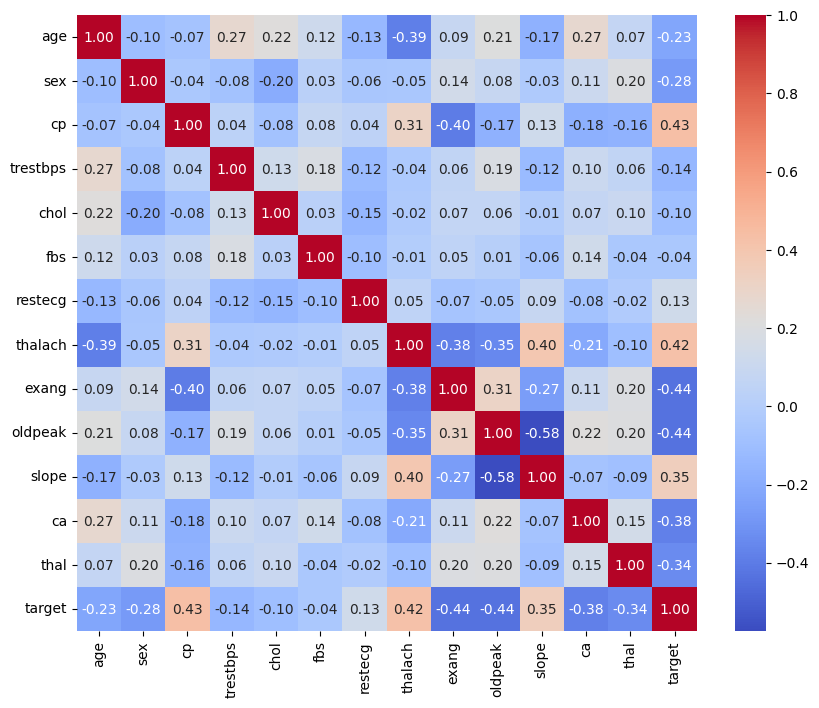

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')

In [11]:
X = df.drop('target', axis=1)

In [13]:
y = df['target']

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [27]:
model = DecisionTreeClassifier(max_depth=6, random_state=42)

In [28]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

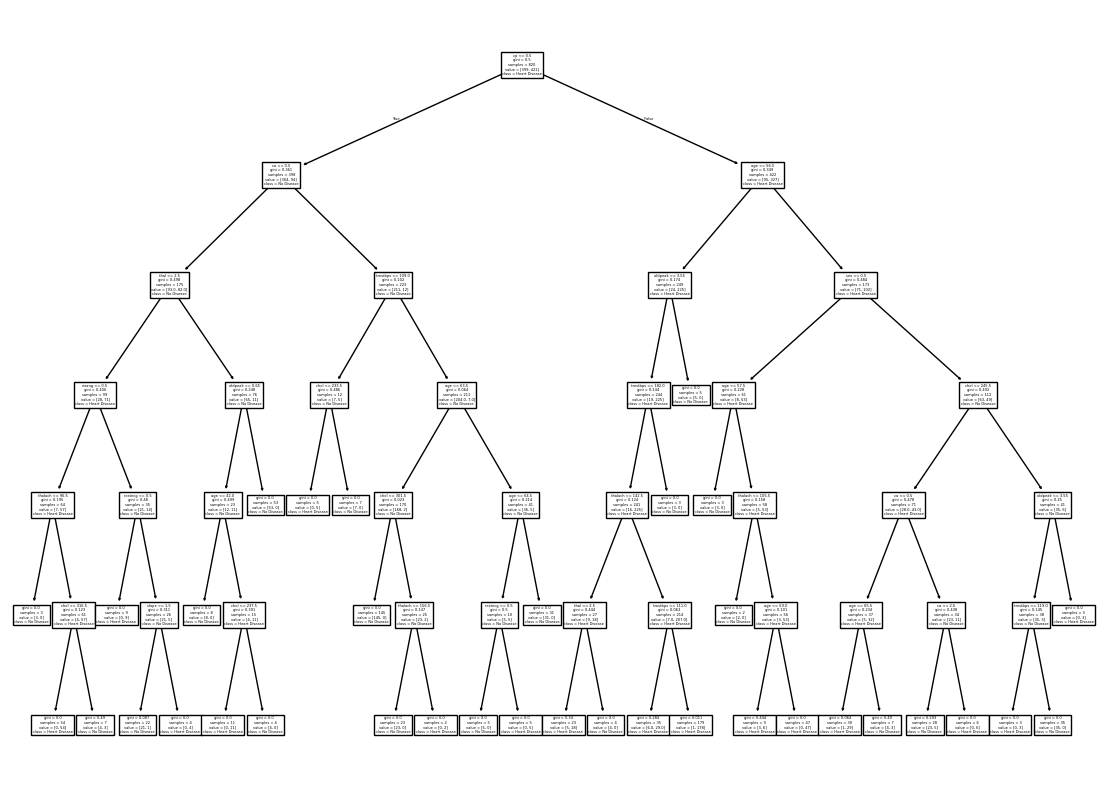

In [29]:
plt.figure(figsize=(14, 10))
plot_tree(model, feature_names=X.columns, class_names=['No Disease', 'Heart Disease'])
plt.show()

In [30]:
prediction = model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [32]:
accuracy = accuracy_score(y_test, prediction)

In [33]:
accuracy

0.9219512195121952

In [35]:
cm = confusion_matrix(y_test, prediction)

In [36]:
cm

array([[90, 10],
       [ 6, 99]])

[ True Positives, False Positives ] 
[ False Negatives, True Negatives ]
